Experimented models: 

ResNet18, Best val acc: 0.9391

ConvNeXt-Tiny,  Best val acc: 0.9664

**Library**

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 with Max-Q Design


device(type='cuda')

In [3]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Seed set to: {SEED}")

Seed set to: 42


**Split**

In [4]:
DATA_DIR = Path(r"C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\RockPaperScissor_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

print("Train dir:", TRAIN_DIR)
print("Val dir  :", VAL_DIR)
print("Test dir :", TEST_DIR)

Train dir: C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\RockPaperScissor_Dataset\train
Val dir  : C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\RockPaperScissor_Dataset\val
Test dir : C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\RockPaperScissor_Dataset\test


**HyperParams**

In [5]:
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 4
EPOCHS       = 15
LR           = 3e-4
WEIGHT_DECAY = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

IMAGE_SIZE: 224
BATCH_SIZE: 32


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [7]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

class_names = train_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("num_classes:", num_classes)
print("Train size:", len(train_ds))
print("Val size:  ", len(val_ds))
print("Test size: ", len(test_ds))

Classes: ['paper', 'rock', 'scissors']
num_classes: 3
Train size: 1020
Val size:   804
Test size:  540


In [8]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

**Visualization**

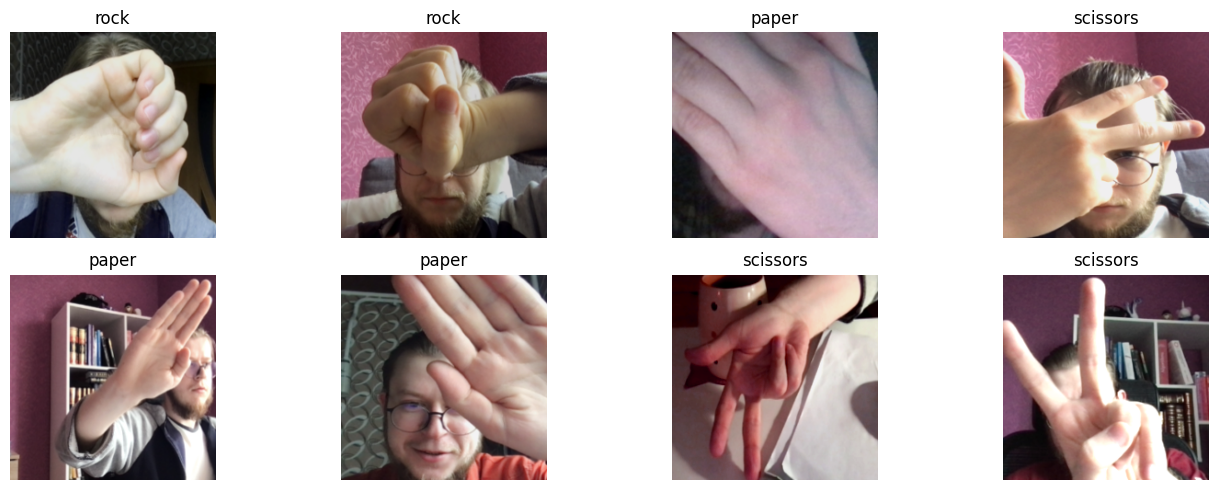

In [9]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

def show_batch(dataloader, class_names, n=8):
    images, labels = next(iter(dataloader))
    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(14, 5))
    
    for i in range(len(images)):
        img = inv_normalize(images[i])
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()

        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

show_batch(train_loader, class_names)

**Model**

In [10]:
# ResNet18
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
ModelCNN = resnet18(weights=weights)

in_features = ModelCNN.fc.in_features
ModelCNN.fc = nn.Linear(in_features, num_classes)

ModelCNN = ModelCNN.to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    ModelCNN.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# # ConvNeXt
# from torchvision.models import ConvNeXt_Tiny_Weights

# try:
#     weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
# except AttributeError:
#     from torchvision.models import ConvNeXt_Tiny_Weights
#     weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1

# ModelCNN = models.convnext_tiny(weights=weights)

# in_features = ModelCNN.classifier[2].in_features
# ModelCNN.classifier[2] = nn.Linear(in_features, num_classes)

# ModelCNN = ModelCNN.to(DEVICE)

# criterion = nn.CrossEntropyLoss()

# optimizer = optim.Adam(
#     ModelCNN.parameters(),
#     lr=LR,
#     weight_decay=WEIGHT_DECAY,
# )


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    verbose=True
)

total_params = sum(p.numel() for p in ModelCNN.parameters())
trainable_params = sum(p.numel() for p in ModelCNN.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print("Device:", DEVICE)
print("Classes:", class_names)

Total params:     11,178,051
Trainable params: 11,178,051
Device: cuda
Classes: ['paper', 'rock', 'scissors']


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [11]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).float().sum().item()
    return correct / targets.size(0)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_acc  += accuracy_from_logits(logits, labels) * batch_size
        n_samples    += batch_size

    return running_loss / n_samples, running_acc / n_samples


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_acc  += accuracy_from_logits(logits, labels) * batch_size
        n_samples    += batch_size

    return running_loss / n_samples, running_acc / n_samples

@torch.no_grad()
def evaluate_test(model, loader, device):
    model.eval()
    total, correct = 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [12]:
from copy import deepcopy

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_state   = None

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(ModelCNN, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = eval_one_epoch(ModelCNN, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
    print(f"  val_loss:   {val_loss:.4f} | val_acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(ModelCNN.state_dict())
        print(f"  ✅ New best val_acc: {best_val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")


Epoch 1/15
  train_loss: 0.2672 | train_acc: 0.8971
  val_loss:   0.3041 | val_acc:   0.8955
  ✅ New best val_acc: 0.8955

Epoch 2/15
  train_loss: 0.1089 | train_acc: 0.9549
  val_loss:   0.4128 | val_acc:   0.8532

Epoch 3/15
  train_loss: 0.0568 | train_acc: 0.9863
  val_loss:   0.2628 | val_acc:   0.8980
  ✅ New best val_acc: 0.8980

Epoch 4/15
  train_loss: 0.0546 | train_acc: 0.9853
  val_loss:   0.3656 | val_acc:   0.8806

Epoch 5/15
  train_loss: 0.0285 | train_acc: 0.9931
  val_loss:   0.2744 | val_acc:   0.9042
  ✅ New best val_acc: 0.9042

Epoch 6/15
  train_loss: 0.0248 | train_acc: 0.9912
  val_loss:   0.2244 | val_acc:   0.9303
  ✅ New best val_acc: 0.9303

Epoch 7/15
  train_loss: 0.0165 | train_acc: 0.9951
  val_loss:   0.5751 | val_acc:   0.8197

Epoch 8/15
  train_loss: 0.0250 | train_acc: 0.9931
  val_loss:   0.2802 | val_acc:   0.9042

Epoch 9/15
  train_loss: 0.0575 | train_acc: 0.9833
  val_loss:   0.3679 | val_acc:   0.8706

Epoch 10/15
  train_loss: 0.0246 | tr

In [13]:
ModelCNN.load_state_dict(best_state)
ModelCNN.to(DEVICE)

test_acc = evaluate_test(ModelCNN, test_loader, DEVICE)
print(f"Test accuracy (same session): {test_acc:.4f}")

Test accuracy (same session): 0.9222


**Checkpoints**

In [14]:
CKPT_DIR = Path("checkpoints_rps_real")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / "resnet18_rps_real_best.pth"

torch.save(
    {
        "model_state": best_state,
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD
    },
    ckpt_path
)

print("Saved best model to:", ckpt_path.resolve())

Saved best model to: C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\checkpoints_rps_real\resnet18_rps_real_best.pth


**Load Checkpoints & Eval Test from Chekpoints**

In [15]:
CKPT_DIR = Path("checkpoints_rps_real")
CKPT_PATH = CKPT_DIR / "resnet18_rps_real_best.pth"

print("Loading checkpoint from:", CKPT_PATH.resolve())
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

class_names = ckpt["class_names"]
num_classes = len(class_names)

# ResNet18 EvalTest
ModelCNN = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
ModelCNN.fc = nn.Linear(ModelCNN.fc.in_features, num_classes)


# # ConvNeXt Evaltest
# IMAGE_SIZE  = ckpt.get("image_size", 224)

# try:
#     weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
# except AttributeError:
#     from torchvision.models import ConvNeXt_Tiny_Weights
#     weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1

# ModelCNN = models.convnext_tiny(weights=weights)

# in_features = ModelCNN.classifier[2].in_features
# ModelCNN.classifier[2] = nn.Linear(in_features, num_classes)


ModelCNN.load_state_dict(ckpt["model_state"])
ModelCNN.to(DEVICE)
ModelCNN.eval()

print("ConvNeXt model rebuilt successfully.")
print("Classes:", class_names)

Loading checkpoint from: C:\Users\ASUS\OneDrive\Documents\1. Aurelio\3. School\BINUS\1. Materi\3rd Semester\MLOps\UTS_MLOps\checkpoints_rps_real\resnet18_rps_real_best.pth
ConvNeXt model rebuilt successfully.
Classes: ['paper', 'rock', 'scissors']


In [16]:
test_acc = evaluate_test(ModelCNN, test_loader, DEVICE)
print("Test accuracy:", test_acc)

Test accuracy: 0.9222222222222223


**Confusion Matrix**

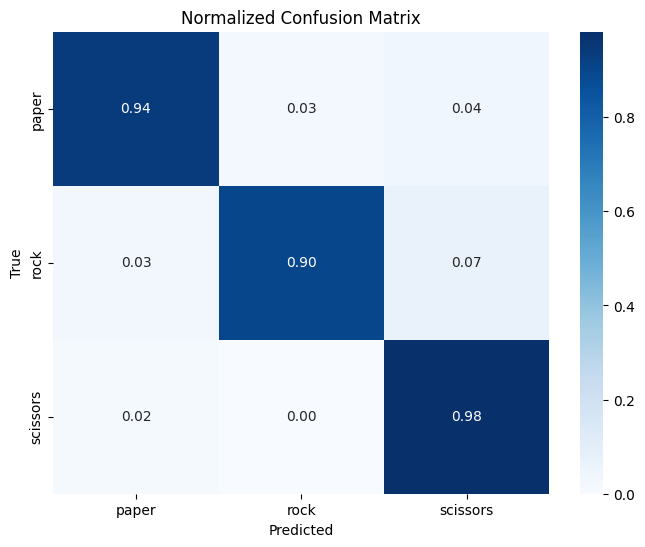

              precision    recall  f1-score   support

       paper       0.95      0.94      0.94       267
        rock       0.97      0.90      0.93       269
    scissors       0.90      0.98      0.94       268

    accuracy                           0.94       804
   macro avg       0.94      0.94      0.94       804
weighted avg       0.94      0.94      0.94       804



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

ModelCNN.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = ModelCNN(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

**Training Curves**

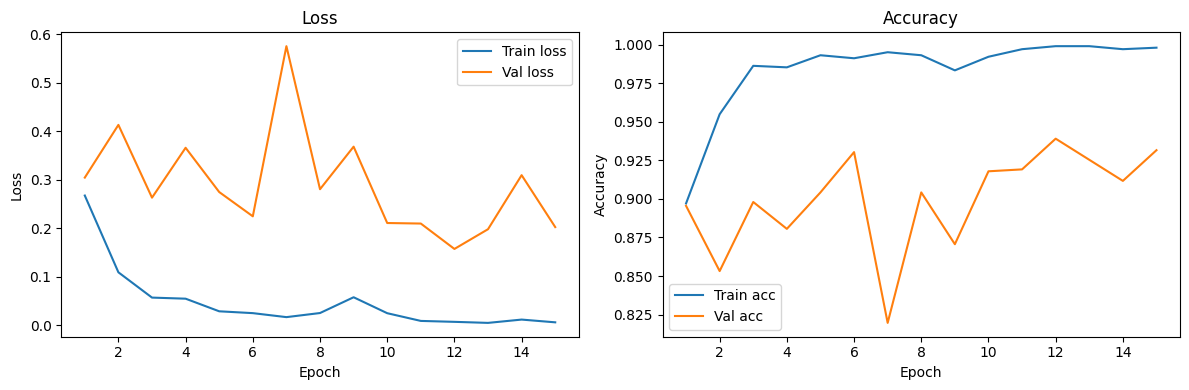

In [18]:
if 'history' not in globals():
    print("Skipping training curves, no training history available (model loaded from checkpoint).")
else:
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train loss")
    plt.plot(epochs_range, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], label="Train acc")
    plt.plot(epochs_range, history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()
    